In [1]:
# ============================================================
#  环境配置
# ============================================================
!pip install torch torchvision matplotlib numpy -U -q
# ── Colab 环境（取消注释后运行） ──
# !pip install torch==2.5.1 torchvision==0.20.1 -q
# !pip install matplotlib==3.9.4 numpy==1.26.4 -q

# ── 本地 Jupyter 环境 ──
# import subprocess, sys
# def _install(pkg):
#     subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

# _install("torch==2.5.1")
# _install("torchvision==0.20.1")
# _install("matplotlib==3.9.4")
# _install("numpy==1.26.4")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 90.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 86.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.3 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.3 which is incompatible.


In [2]:
import math, os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


# Swin Transformer 从零到一：源代码实现 vs 简洁实现

基于论文 *Swin Transformer: Hierarchical Vision Transformer using Shifted Windows* (Liu et al., 2021, ICCV Best Paper)

Swin Transformer 通过**层级式特征图**和**移动窗口自注意力**机制，将 Transformer 的计算复杂度从图像尺寸的平方 $O(N^2)$ 降低为线性 $O(N)$，成为通用的视觉骨干网络。

本 Notebook 包含两种实现：

| | 实现 A — 源代码实现 | 实现 B — 简洁实现 |
|---|---|---|
| 核心思路 | 逐组件手写，含公式推导 | 调用 `torchvision.models.swin_t` |
| 输入尺寸 | 32×32（CIFAR-10 原始） | 224×224（Resize） |
| 架构适配 | Patch=2, Window=4, 小通道数 | 标准 Swin-T 配置 |
| 训练方式 | 从零训练（CPU 友好） | 微调预训练权重 |
| 适合场景 | 理解 Shifted Window 核心机制 | 快速应用、工程落地 |

### Swin Transformer vs ViT 关键区别

| 特性 | ViT | Swin Transformer |
|------|-----|------------------|
| 自注意力范围 | 全局 | 局部窗口 + 移动窗口 |
| 计算复杂度 | $O((H \times W)^2)$ | $O(H \times W)$（窗口大小固定） |
| 特征图尺度 | 单一尺度 | 多尺度层级（类似 CNN） |
| 下游任务 | 主要分类 | 通用 backbone（分类/检测/分割） |

## 1. 数据准备

- **实现 A**：直接使用 CIFAR-10 原始 32×32 图像，适配小型 Swin Transformer
- **实现 B**：将 CIFAR-10 Resize 到 224×224，使用标准 Swin-T 配置

In [3]:
# ── 实现 A 用: 32×32 ──
transform_32 = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomCrop(32, padding=4),
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])
transform_32_test = T.Compose([
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

# ── 实现 B 用: 224×224 ──
transform_224 = T.Compose([
    T.Resize(224),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),  # ImageNet stats
])
transform_224_test = T.Compose([
    T.Resize(224),
    T.ToTensor(),
    T.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

# 下载 CIFAR-10 + 子集
train_32 = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_32)
test_32 = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_32_test)
train_32_sub = Subset(train_32, list(range(5000)))
test_32_sub = Subset(test_32, list(range(1000)))

train_224 = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=transform_224)
test_224 = torchvision.datasets.CIFAR10(root='./data', train=False, download=False, transform=transform_224_test)
train_224_sub = Subset(train_224, list(range(2000)))  # 更少样本（224×224 更慢）
test_224_sub = Subset(test_224, list(range(500)))

print(f'实现 A 数据: train={len(train_32_sub)}, test={len(test_32_sub)}, size=32×32')
print(f'实现 B 数据: train={len(train_224_sub)}, test={len(test_224_sub)}, size=224×224')

100%|██████████| 170M/170M [00:16<00:00, 10.3MB/s]


实现 A 数据: train=5000, test=1000, size=32×32
实现 B 数据: train=2000, test=500, size=224×224


In [4]:
# ── 超参数 ──
# 实现 A: 小型 Swin (适配 32×32)
PATCH_SIZE_A   = 2      # 将 32×32 切为 16×16 个 patch
EMBED_DIM_A    = 48     # 嵌入维度（论文 96，缩小）
DEPTHS_A       = [2, 2, 2]  # 3 个 Stage（论文 4 个，减少）
NUM_HEADS_A    = [3, 6, 12]
WINDOW_SIZE_A  = 4      # 窗口大小: 4×4 个 patch（论文 7）
MLP_RATIO      = 4.0
DROPOUT        = 0.1
NUM_CLASSES    = 10

# 实现 B: 标准 Swin-T (224×224)
# patch_size=4, embed_dim=96, depths=[2,2,6,2], num_heads=[3,6,12,24], window_size=7

LR           = 1e-3
NUM_EPOCHS_A = 30       # CPU 友好
NUM_EPOCHS_B = 10       # 微调轮数较少
BATCH_SIZE_A = 64
BATCH_SIZE_B = 16       # 224×224 内存占用大

loader_a_train = DataLoader(train_32_sub, batch_size=BATCH_SIZE_A, shuffle=True, num_workers=0)
loader_a_test = DataLoader(test_32_sub, batch_size=BATCH_SIZE_A, num_workers=0)
loader_b_train = DataLoader(train_224_sub, batch_size=BATCH_SIZE_B, shuffle=True, num_workers=0)
loader_b_test = DataLoader(test_224_sub, batch_size=BATCH_SIZE_B, num_workers=0)

## 2. 共享组件

In [5]:
def train_model(model, train_loader, test_loader, num_epochs, lr, device):
    """通用训练循环."""
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.05)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    criterion = nn.CrossEntropyLoss()
    train_losses, test_accs = [], []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            loss = criterion(model(x), y)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item()
        scheduler.step()
        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)

        # 测试
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                correct += (model(x).argmax(1) == y).sum().item()
                total += y.size(0)
        acc = correct / total
        test_accs.append(acc)

        if (epoch + 1) % 5 == 0:
            print(f'  Epoch [{epoch+1}/{num_epochs}]  Loss: {avg_loss:.4f}  Acc: {acc:.4f}')

    return train_losses, test_accs

## 3. 实现 A — 源代码实现

按 Swin Transformer 的数据流逐组件实现：

1. **Patch Partition + Linear Embedding** — 图像切块并嵌入
2. **Window Partition / Reverse** — 窗口划分与还原
3. **Window Attention (W-MSA)** — 窗口内自注意力 + 相对位置偏置
4. **Shifted Window Attention (SW-MSA)** — 移动窗口注意力（循环移位 + 掩码）
5. **Swin Transformer Block** — W-MSA 与 SW-MSA 交替
6. **Patch Merging** — 下采样（分辨率减半、通道加倍）
7. **完整模型** — 组装所有组件

### 3.1 Patch Partition + Linear Embedding

将输入图像切割为不重叠的 Patch，每个 Patch 展平后通过线性层映射到嵌入空间：

$$\text{输入}: (B, 3, H, W) \xrightarrow{\text{Patch Partition}} (B, \frac{H}{P} \times \frac{W}{P}, P^2 \times 3) \xrightarrow{\text{Linear}} (B, \frac{H}{P} \times \frac{W}{P}, C)$$

对于 32×32 输入、Patch 大小 2：切为 $16 \times 16 = 256$ 个 Patch，每个维度 $2 \times 2 \times 3 = 12$，映射到 $C = 48$。

In [6]:
class PatchEmbedding(nn.Module):
    """Patch Partition + Linear Embedding.
    (B, 3, H, W) -> (B, H/P * W/P, embed_dim)
    """
    def __init__(self, patch_size=2, in_channels=3, embed_dim=48):
        super().__init__()
        self.patch_size = patch_size
        # 用卷积同时完成切块和线性映射
        self.proj = nn.Conv2d(in_channels, embed_dim,
                              kernel_size=patch_size, stride=patch_size)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        # x: (B, 3, H, W)
        x = self.proj(x)          # (B, embed_dim, H/P, W/P)
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)  # (B, H/P*W/P, embed_dim)
        x = self.norm(x)
        return x, H, W  # 返回空间尺寸用于后续窗口划分

# 验证
_pe = PatchEmbedding(PATCH_SIZE_A, 3, EMBED_DIM_A)
_out, _h, _w = _pe(torch.randn(2, 3, 32, 32))
print(f'PatchEmbedding: (2, 3, 32, 32) -> {_out.shape}, spatial=({_h}, {_w})')
# 预期: (2, 256, 48), spatial=(16, 16)

PatchEmbedding: (2, 3, 32, 32) -> torch.Size([2, 256, 48]), spatial=(16, 16)


### 3.2 窗口划分与还原 (Window Partition / Reverse)

将特征图划分为不重叠的固定大小窗口，每个窗口内独立计算自注意力：

$$\text{特征图}: (B, H, W, C) \xrightarrow{\text{partition}} (B \times \frac{H}{M} \times \frac{W}{M},\; M \times M,\; C)$$

其中 $M$ 是窗口大小（这里 $M = 4$）。

划分后每个窗口变成一个独立的"小序列"，窗口之间互不干扰 → 自注意力复杂度从 $O((HW)^2)$ 降为 $O(M^2 \cdot HW)$，即关于 $HW$ 为**线性**。

In [7]:
def window_partition(x, window_size):
    """将特征图划分为不重叠窗口.
    x: (B, H, W, C)
    Returns: (num_windows * B, window_size, window_size, C)
    """
    B, H, W, C = x.shape
    # reshape 为 (B, H//M, M, W//M, M, C)
    x = x.view(B, H // window_size, window_size,
                W // window_size, window_size, C)
    # permute 为 (B, H//M, W//M, M, M, C)，然后合并前三维
    windows = x.permute(0, 1, 3, 2, 4, 5).contiguous()
    windows = windows.view(-1, window_size, window_size, C)
    return windows  # (num_windows*B, M, M, C)


def window_reverse(windows, window_size, H, W):
    """将窗口还原为完整特征图.
    windows: (num_windows*B, M, M, C)
    Returns: (B, H, W, C)
    """
    B = int(windows.shape[0] / (H * W / window_size / window_size))
    x = windows.view(B, H // window_size, W // window_size,
                     window_size, window_size, -1)
    x = x.permute(0, 1, 3, 2, 4, 5).contiguous()
    return x.view(B, H, W, -1)  # (B, H, W, C)

# 验证: 划分后还原应恢复原始形状
_x = torch.randn(2, 16, 16, 48)
_w = window_partition(_x, WINDOW_SIZE_A)
print(f'Window partition: (2, 16, 16, 48) -> {_w.shape}')
# (2*4*4, 4, 4, 48) = (32, 4, 4, 48)
_r = window_reverse(_w, WINDOW_SIZE_A, 16, 16)
print(f'Window reverse:  {_w.shape} -> {_r.shape}')
assert torch.allclose(_x, _r), 'Window partition/reverse mismatch!'
print('Window partition/reverse consistency check passed')

Window partition: (2, 16, 16, 48) -> torch.Size([32, 4, 4, 48])
Window reverse:  torch.Size([32, 4, 4, 48]) -> torch.Size([2, 16, 16, 48])
Window partition/reverse consistency check passed


### 3.3 窗口自注意力 (W-MSA) + 相对位置偏置

在每个窗口内独立计算多头自注意力：

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d}} + B\right) V$$

其中 $B$ 是**相对位置偏置**（Relative Position Bias），替代 ViT 中的绝对位置编码。

#### 相对位置偏置表
- 窗口大小 $M \times M$ 中，相对位置范围为 $[-(M-1), M-1]$，每个维度 $2M-1$ 种取值
- 构建可学习参数表 `relative_position_bias_table`: $(2M-1)^2 \times \text{num\_heads}$
- 通过坐标索引查表得到每对 token 的位置偏置

#### 复杂度对比

$$\Omega(\text{MSA}) = 4hwC^2 + 2(hw)^2C$$
$$\Omega(\text{W-MSA}) = 4hwC^2 + 2M^2hwC$$

当 $M$ 固定时，W-MSA 关于 $hw$ 为线性。

In [8]:
class WindowAttention(nn.Module):
    """窗口多头自注意力 + 相对位置偏置.
    输入: (num_windows*B, M*M, C) -> 输出: (num_windows*B, M*M, C)
    """
    def __init__(self, dim, window_size, num_heads, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.dim = dim
        self.window_size = window_size  # (M, M)
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5

        # 相对位置偏置参数表: (2M-1)*(2M-1) x num_heads
        self.relative_position_bias_table = nn.Parameter(
            torch.zeros((2 * window_size - 1) * (2 * window_size - 1), num_heads)
        )
        nn.init.trunc_normal_(self.relative_position_bias_table, std=0.02)

        # 计算相对位置索引
        coords_h = torch.arange(window_size)
        coords_w = torch.arange(window_size)
        coords = torch.stack(torch.meshgrid(coords_h, coords_w, indexing='ij'))  # (2, M, M)
        coords_flatten = coords.view(2, -1)  # (2, M*M)
        # 相对坐标: (2, M*M, M*M)
        relative_coords = coords_flatten[:, :, None] - coords_flatten[:, None, :]
        relative_coords = relative_coords.permute(1, 2, 0).contiguous()  # (M*M, M*M, 2)
        relative_coords[:, :, 0] += window_size - 1  # 偏移到非负
        relative_coords[:, :, 1] += window_size - 1
        relative_coords[:, :, 0] *= 2 * window_size - 1  # 展平二维索引
        relative_position_index = relative_coords.sum(-1)  # (M*M, M*M)
        self.register_buffer('relative_position_index', relative_position_index)

        self.qkv = nn.Linear(dim, dim * 3)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x, mask=None):
        """
        x: (num_windows*B, N, C) where N = M*M
        mask: (num_windows, N, N) or None
        """
        B_, N, C = x.shape  # B_ = num_windows * B
        # QKV: (B_, N, 3*C) -> (B_, N, 3, num_heads, head_dim) -> (3, B_, num_heads, N, head_dim)
        qkv = self.qkv(x).reshape(B_, N, 3, self.num_heads, C // self.num_heads)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)  # 各 (B_, num_heads, N, head_dim)

        # 注意力分数: (B_, num_heads, N, N)
        attn = (q @ k.transpose(-2, -1)) * self.scale

        # 加入相对位置偏置
        relative_position_bias = self.relative_position_bias_table[
            self.relative_position_index.view(-1)
        ].view(N, N, -1)  # (N, N, num_heads)
        relative_position_bias = relative_position_bias.permute(2, 0, 1)  # (num_heads, N, N)
        attn = attn + relative_position_bias.unsqueeze(0)

        # 如果有掩码（SW-MSA 用）
        if mask is not None:
            nW = mask.shape[0]  # num_windows
            # attn: (B_/nW, nW, num_heads, N, N) -> 加 mask
            attn = attn.view(B_ // nW, nW, self.num_heads, N, N)
            attn = attn + mask.unsqueeze(1).unsqueeze(0)  # 广播
            attn = attn.view(-1, self.num_heads, N, N)

        attn = F.softmax(attn, dim=-1)
        attn = self.attn_drop(attn)

        # 加权求和: (B_, num_heads, N, head_dim) -> (B_, N, C)
        x = (attn @ v).transpose(1, 2).reshape(B_, N, C)
        x = self.proj_drop(self.proj(x))
        return x

_wa = WindowAttention(EMBED_DIM_A, WINDOW_SIZE_A, NUM_HEADS_A[0])
_out = _wa(torch.randn(32, 16, 48))
print(f'WindowAttention: (32, 16, 48) -> {_out.shape}')

WindowAttention: (32, 16, 48) -> torch.Size([32, 16, 48])


### 3.4 移动窗口机制 (Shifted Window / SW-MSA)

#### 为什么需要移动窗口？
固定窗口内自注意力虽然高效，但窗口之间没有信息交互。移动窗口通过**循环移位**实现跨窗口通信。

#### 循环移位实现 (Cyclic Shift)

1. **移位**：将特征图向左上方移动 $\lfloor M/2 \rfloor$ 个 Patch
2. **重新划分**：在移位后的特征图上正常划分窗口
3. **掩码注意力**：移位后同一窗口内可能包含不相邻区域，通过掩码矩阵屏蔽
4. **逆移位**：计算完成后移回原位

#### 掩码矩阵
移位后，一个窗口内的 Patch 可能来自不同的原始窗口。对于不应交互的区域，掩码值设为 $-100$，经 softmax 后趋近于 0：

$$\text{softmax}(A + \text{Mask})$$

### Swin Transformer Block

每个 Block 由一对子块组成，交替使用 W-MSA 和 SW-MSA：

$$\hat{\mathbf{z}}^l = \text{W-MSA}(\text{LN}(\mathbf{z}^{l-1})) + \mathbf{z}^{l-1}$$
$$\mathbf{z}^l = \text{MLP}(\text{LN}(\hat{\mathbf{z}}^l)) + \hat{\mathbf{z}}^l$$
$$\hat{\mathbf{z}}^{l+1} = \text{SW-MSA}(\text{LN}(\mathbf{z}^l)) + \mathbf{z}^l$$
$$\mathbf{z}^{l+1} = \text{MLP}(\text{LN}(\hat{\mathbf{z}}^{l+1})) + \hat{\mathbf{z}}^{l+1}$$

In [9]:
class SwinTransformerBlock(nn.Module):
    """Swin Transformer Block: W-MSA 或 SW-MSA + MLP.

    (B, H*W, C) -> Attention -> MLP -> (B, H*W, C)
    """
    def __init__(self, dim, num_heads, window_size=4, shift_size=0,
                 mlp_ratio=4., drop=0., attn_drop=0.):
        super().__init__()
        self.dim = dim
        self.num_heads = num_heads
        self.window_size = window_size
        self.shift_size = shift_size  # 0 = W-MSA, >0 = SW-MSA
        self.mlp_ratio = mlp_ratio

        self.norm1 = nn.LayerNorm(dim)
        self.attn = WindowAttention(dim, window_size, num_heads, attn_drop, drop)
        self.norm2 = nn.LayerNorm(dim)
        mlp_hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_hidden),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(mlp_hidden, dim),
            nn.Dropout(drop),
        )

    def _compute_attn_mask(self, H, W, device):
        """计算 SW-MSA 的注意力掩码."""
        if self.shift_size == 0:
            return None

        # 创建区域标记图
        img_mask = torch.zeros(1, H, W, 1, device=device)
        h_slices = (slice(0, -self.window_size),
                    slice(-self.window_size, -self.shift_size),
                    slice(-self.shift_size, None))
        w_slices = (slice(0, -self.window_size),
                    slice(-self.window_size, -self.shift_size),
                    slice(-self.shift_size, None))
        cnt = 0
        for h in h_slices:
            for w in w_slices:
                img_mask[:, h, w, :] = cnt
                cnt += 1

        # 划分窗口
        mask_windows = window_partition(img_mask, self.window_size)  # (nW, M, M, 1)
        mask_windows = mask_windows.view(-1, self.window_size * self.window_size)  # (nW, M*M)

        # 构建掩码: 同一区域=0，不同区域=-100
        attn_mask = mask_windows.unsqueeze(1) - mask_windows.unsqueeze(2)  # (nW, M*M, M*M)
        attn_mask = attn_mask.masked_fill(attn_mask != 0, -100.0)
        return attn_mask  # (nW, M*M, M*M)

    def forward(self, x, H, W):
        """
        x: (B, H*W, C)
        """
        B, L, C = x.shape
        shortcut = x

        # 当空间分辨率 <= 窗口大小时，禁用 shift（仅一个窗口，无需跨窗口交互）
        effective_shift = self.shift_size if min(H, W) > self.window_size else 0

        x = self.norm1(x)
        x = x.view(B, H, W, C)

        # 循环移位 (Cyclic Shift)
        if effective_shift > 0:
            shifted_x = torch.roll(x, shifts=(-effective_shift, -effective_shift), dims=(1, 2))
        else:
            shifted_x = x

        # 窗口划分
        x_windows = window_partition(shifted_x, self.window_size)  # (nW*B, M, M, C)
        x_windows = x_windows.view(-1, self.window_size * self.window_size, C)  # (nW*B, M*M, C)

        # 窗口自注意力（带掩码）— 仅在 effective_shift > 0 时需要掩码
        attn_mask = self._compute_attn_mask(H, W, x.device) if effective_shift > 0 else None
        attn_windows = self.attn(x_windows, mask=attn_mask)  # (nW*B, M*M, C)

        # 还原窗口
        attn_windows = attn_windows.view(-1, self.window_size, self.window_size, C)
        shifted_x = window_reverse(attn_windows, self.window_size, H, W)  # (B, H, W, C)

        # 逆循环移位
        if effective_shift > 0:
            x = torch.roll(shifted_x, shifts=(effective_shift, effective_shift), dims=(1, 2))
        else:
            x = shifted_x

        x = x.view(B, H * W, C)

        # 残差连接 + MLP
        x = shortcut + x
        x = x + self.mlp(self.norm2(x))
        return x

# 验证
_blk = SwinTransformerBlock(EMBED_DIM_A, NUM_HEADS_A[0], WINDOW_SIZE_A, shift_size=0)
_out = _blk(torch.randn(2, 256, 48), 16, 16)
print(f'SwinBlock (W-MSA): (2, 256, 48) -> {_out.shape}')

_blk_s = SwinTransformerBlock(EMBED_DIM_A, NUM_HEADS_A[0], WINDOW_SIZE_A,
                               shift_size=WINDOW_SIZE_A // 2)
_out_s = _blk_s(torch.randn(2, 256, 48), 16, 16)
print(f'SwinBlock (SW-MSA): (2, 256, 48) -> {_out_s.shape}')

# 验证: Stage 3 (4x4) 时 SW-MSA 自动禁用 shift
_blk_s3 = SwinTransformerBlock(EMBED_DIM_A * 4, NUM_HEADS_A[-1], WINDOW_SIZE_A,
                                shift_size=WINDOW_SIZE_A // 2)
_out_s3 = _blk_s3(torch.randn(2, 16, 192), 4, 4)
print(f'SwinBlock (SW-MSA, H=W=window_size): (2, 16, 192) -> {_out_s3.shape}  [shift auto-disabled]')

SwinBlock (W-MSA): (2, 256, 48) -> torch.Size([2, 256, 48])
SwinBlock (SW-MSA): (2, 256, 48) -> torch.Size([2, 256, 48])
SwinBlock (SW-MSA, H=W=window_size): (2, 16, 192) -> torch.Size([2, 16, 192])  [shift auto-disabled]


### 3.5 Patch Merging（下采样）

类似 CNN 中的池化操作，Patch Merging 将空间分辨率减半、通道数加倍：

$$\text{输入}: (B, H, W, C) \xrightarrow{\text{隔行隔列采样}} 4 \times (B, H/2, W/2, C) \xrightarrow{\text{拼接}} (B, H/2, W/2, 4C) \xrightarrow{\text{线性}} (B, H/2, W/2, 2C)$$

这使 Swin Transformer 能像 CNN 一样构建**金字塔特征图**，适配 FPN（检测）和 U-Net（分割）。

In [10]:
class PatchMerging(nn.Module):
    """Patch Merging: 空间减半，通道加倍.
    (B, H*W, C) -> (B, H/2*W/2, 2C)
    """
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        self.reduction = nn.Linear(4 * dim, 2 * dim, bias=False)
        self.norm = nn.LayerNorm(4 * dim)

    def forward(self, x, H, W):
        # x: (B, H*W, C)
        B, L, C = x.shape
        x = x.view(B, H, W, C)

        # 隔行隔列采样: 4 个 (B, H/2, W/2, C)
        x0 = x[:, 0::2, 0::2, :]  # 左上
        x1 = x[:, 1::2, 0::2, :]  # 左下
        x2 = x[:, 0::2, 1::2, :]  # 右上
        x3 = x[:, 1::2, 1::2, :]  # 右下

        # 拼接: (B, H/2, W/2, 4C)
        x = torch.cat([x0, x1, x2, x3], dim=-1)
        x = x.view(B, -1, 4 * C)  # (B, H/2*W/2, 4C)

        x = self.norm(x)
        x = self.reduction(x)  # (B, H/2*W/2, 2C)
        return x, H // 2, W // 2

_pm = PatchMerging(EMBED_DIM_A)
_out, _h2, _w2 = _pm(torch.randn(2, 256, 48), 16, 16)
print(f'PatchMerging: (2, 256, 48) -> {_out.shape}, spatial=({_h2}, {_w2})')
# 预期: (2, 64, 96), spatial=(8, 8)

PatchMerging: (2, 256, 48) -> torch.Size([2, 64, 96]), spatial=(8, 8)


### 3.6 完整 Swin Transformer

将所有组件组装为完整模型。每个 Stage 包含偶数个 Block（W-MSA 和 SW-MSA 交替），Stage 之间通过 Patch Merging 下采样。

对于 32×32 CIFAR-10 适配版本：
```
Stage 1: (B, 256, 48)  -> 2 blocks -> (B, 256, 48)   -> PatchMerging -> (B, 64, 96)
Stage 2: (B, 64, 96)   -> 2 blocks -> (B, 64, 96)    -> PatchMerging -> (B, 16, 192)
Stage 3: (B, 16, 192)  -> 2 blocks -> (B, 16, 192)   -> AvgPool -> (B, 192) -> Linear -> (B, 10)
```

In [11]:
class SwinTransformer(nn.Module):
    """Swin Transformer 完整模型（小型版，适配 32x32）.

    (B, 3, 32, 32) -> PatchEmbed -> [Stage1 -> PM -> Stage2 -> PM -> Stage3] -> Head -> (B, num_classes)
    """
    def __init__(self, patch_size=2, in_channels=3, embed_dim=48,
                 depths=(2, 2, 2), num_heads=(3, 6, 12),
                 window_size=4, mlp_ratio=4., drop_rate=0.1,
                 num_classes=10):
        super().__init__()
        self.num_stages = len(depths)
        self.embed_dim = embed_dim

        # Patch Embedding
        self.patch_embed = PatchEmbedding(patch_size, in_channels, embed_dim)

        # 构建各 Stage
        self.stages = nn.ModuleList()
        self.downsamples = nn.ModuleList()

        for i_stage in range(self.num_stages):
            dim = embed_dim * (2 ** i_stage)
            blocks = nn.ModuleList()
            for i_block in range(depths[i_stage]):
                shift = 0 if (i_block % 2 == 0) else window_size // 2
                blocks.append(SwinTransformerBlock(
                    dim=dim, num_heads=num_heads[i_stage],
                    window_size=window_size, shift_size=shift,
                    mlp_ratio=mlp_ratio, drop=drop_rate,
                ))
            self.stages.append(blocks)

            # 最后一个 Stage 不需要下采样
            if i_stage < self.num_stages - 1:
                self.downsamples.append(PatchMerging(dim))
            else:
                self.downsamples.append(nn.Identity())

        final_dim = embed_dim * (2 ** (self.num_stages - 1))
        self.norm = nn.LayerNorm(final_dim)
        self.head = nn.Linear(final_dim, num_classes)

    def forward(self, x):
        # x: (B, 3, 32, 32)
        x, H, W = self.patch_embed(x)  # (B, 256, 48), H=16, W=16

        for i_stage in range(self.num_stages):
            for block in self.stages[i_stage]:
                x = block(x, H, W)

            if i_stage < self.num_stages - 1:
                x, H, W = self.downsamples[i_stage](x, H, W)

        # Global Average Pooling
        x = self.norm(x)          # (B, H*W, C)
        x = x.mean(dim=1)        # (B, C)
        x = self.head(x)         # (B, num_classes)
        return x

model_a = SwinTransformer(
    patch_size=PATCH_SIZE_A, embed_dim=EMBED_DIM_A,
    depths=DEPTHS_A, num_heads=NUM_HEADS_A,
    window_size=WINDOW_SIZE_A, mlp_ratio=MLP_RATIO,
    drop_rate=DROPOUT, num_classes=NUM_CLASSES,
)
_out = model_a(torch.randn(2, 3, 32, 32))
print(f'SwinTransformer: (2, 3, 32, 32) -> {_out.shape}')
print(f'Total params: {sum(p.numel() for p in model_a.parameters()):,}')

SwinTransformer: (2, 3, 32, 32) -> torch.Size([2, 10])
Total params: 1,268,356


### 3.7 训练

=== 实现 A: 源代码 Swin Transformer — 训练 ===
  Epoch [5/30]  Loss: 1.7577  Acc: 0.3510
  Epoch [10/30]  Loss: 1.4890  Acc: 0.4120
  Epoch [15/30]  Loss: 1.3464  Acc: 0.4780
  Epoch [20/30]  Loss: 1.2260  Acc: 0.5300
  Epoch [25/30]  Loss: 1.0901  Acc: 0.5350
  Epoch [30/30]  Loss: 1.0410  Acc: 0.5370


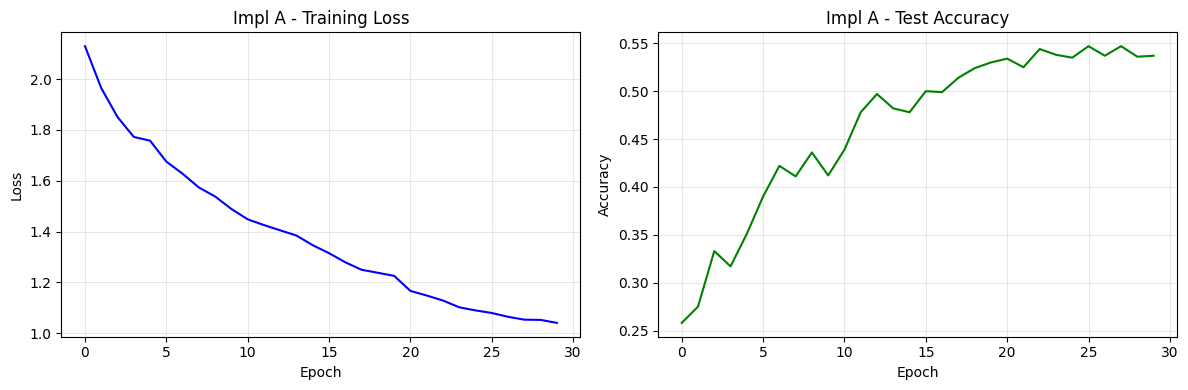

实现 A 最终准确率: 0.5370


In [12]:
print('=== 实现 A: 源代码 Swin Transformer — 训练 ===')
losses_a, accs_a = train_model(model_a, loader_a_train, loader_a_test,
                                NUM_EPOCHS_A, LR, device)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(losses_a, 'b-'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Impl A - Training Loss'); axes[0].grid(True, alpha=0.3)
axes[1].plot(accs_a, 'g-'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Impl A - Test Accuracy'); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(f'实现 A 最终准确率: {accs_a[-1]:.4f}')

## 4. 实现 B — 简洁实现 (torchvision.models.swin_t)

使用 PyTorch 官方 `torchvision.models.swin_t` 预训练模型，微调分类头用于 CIFAR-10。

| 源代码实现 | 简洁实现 (torchvision) |
|---|---|
| `PatchEmbedding` | 内置 Patch Partition + Linear Embedding |
| `WindowAttention` | 内置 W-MSA + 相对位置偏置 |
| `SwinTransformerBlock` | 内置 Block (W-MSA <-> SW-MSA 交替) |
| `PatchMerging` | 内置 Patch Merging |
| `SwinTransformer` | `torchvision.models.swin_t(weights=...)` |

### Swin-T 标准配置
- `patch_size=[4, 4]`, `embed_dim=96`
- `depths=[2, 2, 6, 2]`, `num_heads=[3, 6, 12, 24]`
- `window_size=[7, 7]`
- 输入: 224×224

In [13]:
from torchvision.models import swin_t, Swin_T_Weights

# 加载预训练权重
model_b = swin_t(weights=Swin_T_Weights.IMAGENET1K_V1)

# 修改分类头: 1000 -> 10 (CIFAR-10)
model_b.head = nn.Linear(model_b.head.in_features, NUM_CLASSES)

# 冻结除分类头外的所有参数（仅微调 head）
for name, param in model_b.named_parameters():
    if 'head' not in name:
        param.requires_grad = False

trainable = sum(p.numel() for p in model_b.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_b.parameters())
print(f'Model B (Swin-T):')
print(f'  Total params:     {total:,}')
print(f'  Trainable params: {trainable:,} (仅分类头)')
print(f'  Frozen params:    {total - trainable:,}')

Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 163MB/s]


Model B (Swin-T):
  Total params:     27,527,044
  Trainable params: 7,690 (仅分类头)
  Frozen params:    27,519,354


=== 实现 B: Swin-T 微调 — 训练 ===
  Epoch [5/10]  Loss: 0.2905  Acc: 0.8840
  Epoch [10/10]  Loss: 0.2220  Acc: 0.8940


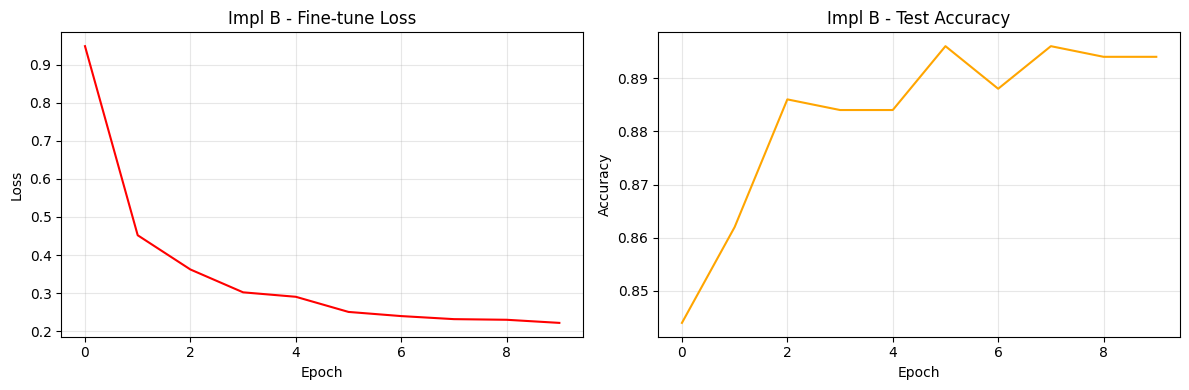

实现 B 最终准确率: 0.8940


In [14]:
print('=== 实现 B: Swin-T 微调 — 训练 ===')
losses_b, accs_b = train_model(model_b, loader_b_train, loader_b_test,
                                NUM_EPOCHS_B, 1e-3, device)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(losses_b, 'r-'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Impl B - Fine-tune Loss'); axes[0].grid(True, alpha=0.3)
axes[1].plot(accs_b, 'orange'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Impl B - Test Accuracy'); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(f'实现 B 最终准确率: {accs_b[-1]:.4f}')

## 5. 结果对比

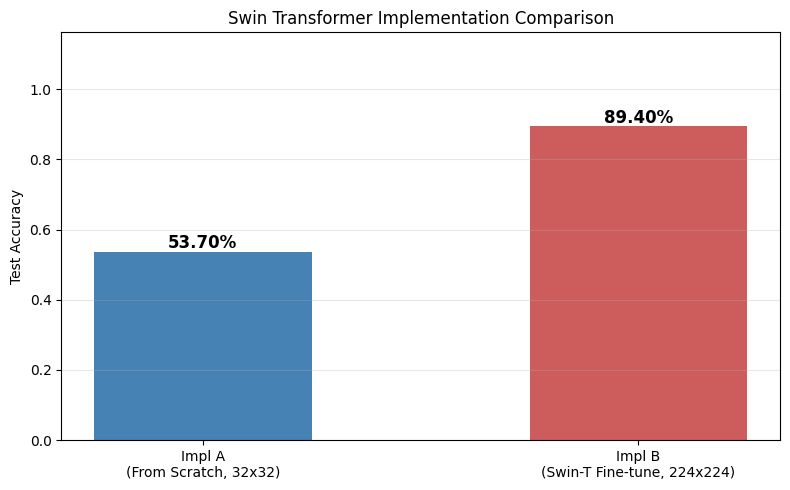

实现 A (源代码, 32x32):    0.5370
实现 B (Swin-T 微调, 224): 0.8940

注: 实现 B 使用 ImageNet 预训练权重，即使只微调分类头也能获得不错效果


In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(['Impl A\n(From Scratch, 32x32)', 'Impl B\n(Swin-T Fine-tune, 224x224)'],
              [accs_a[-1], accs_b[-1]],
              color=['steelblue', 'indianred'], width=0.5)
ax.set_ylabel('Test Accuracy'); ax.set_title('Swin Transformer Implementation Comparison')
ax.set_ylim(0, max(accs_a[-1], accs_b[-1]) * 1.3)
for bar, acc in zip(bars, [accs_a[-1], accs_b[-1]]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.2%}', ha='center', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

print(f'实现 A (源代码, 32x32):    {accs_a[-1]:.4f}')
print(f'实现 B (Swin-T 微调, 224): {accs_b[-1]:.4f}')
print(f'\n注: 实现 B 使用 ImageNet 预训练权重，即使只微调分类头也能获得不错效果')

## 附录 A：可视化

### 窗口注意力与循环移位可视化

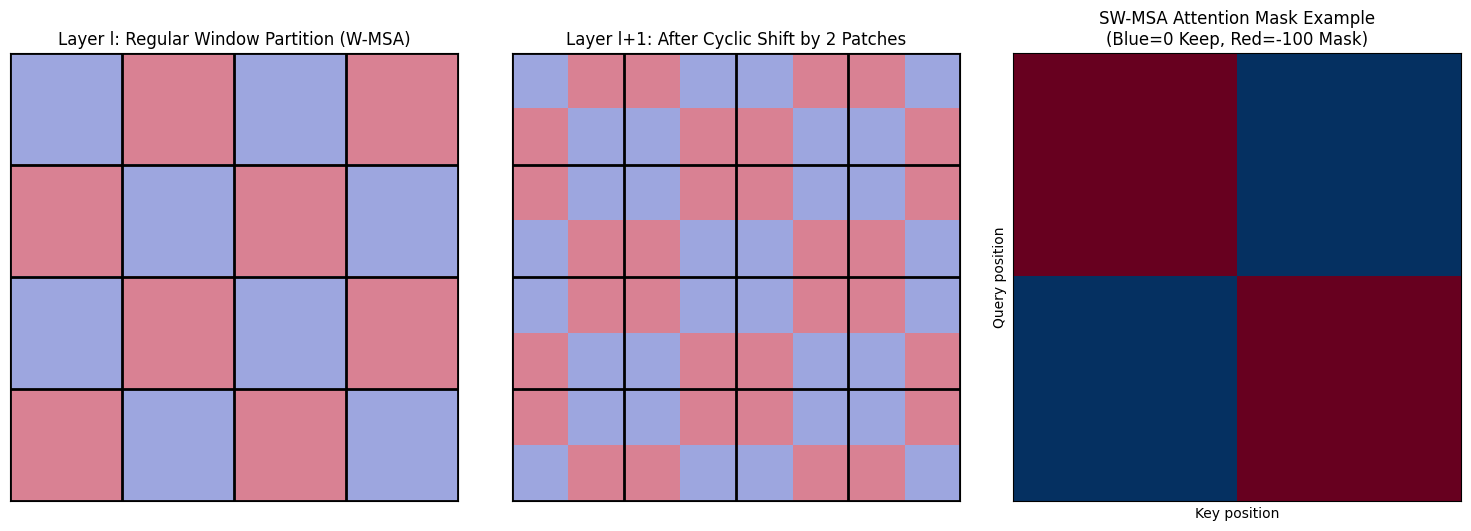

In [16]:
# ── 窗口划分与循环移位可视化 ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 原始窗口划分
grid = np.zeros((16, 16))
for i in range(0, 16, WINDOW_SIZE_A):
    for j in range(0, 16, WINDOW_SIZE_A):
        grid[i:i+WINDOW_SIZE_A, j:j+WINDOW_SIZE_A] = ((i//WINDOW_SIZE_A + j//WINDOW_SIZE_A) % 2)

axes[0].imshow(grid, cmap='coolwarm', alpha=0.5)
axes[0].set_title('Layer l: Regular Window Partition (W-MSA)')
for i in range(0, 17, WINDOW_SIZE_A):
    axes[0].axhline(i-0.5, color='black', linewidth=2)
    axes[0].axvline(i-0.5, color='black', linewidth=2)

# 循环移位后
shift = WINDOW_SIZE_A // 2
shifted_grid = np.roll(np.roll(grid, -shift, axis=0), -shift, axis=1)
axes[1].imshow(shifted_grid, cmap='coolwarm', alpha=0.5)
axes[1].set_title(f'Layer l+1: After Cyclic Shift by {shift} Patches')
for i in range(0, 17, WINDOW_SIZE_A):
    axes[1].axhline(i-0.5, color='black', linewidth=2)
    axes[1].axvline(i-0.5, color='black', linewidth=2)

# 掩码示意
mask_demo = np.zeros((WINDOW_SIZE_A**2, WINDOW_SIZE_A**2))
# 模拟一个需要掩码的窗口
half = WINDOW_SIZE_A * (WINDOW_SIZE_A // 2)
mask_demo[:half, half:] = -100
mask_demo[half:, :half] = -100
axes[2].imshow(mask_demo, cmap='RdBu_r', vmin=-100, vmax=0)
axes[2].set_title('SW-MSA Attention Mask Example\n(Blue=0 Keep, Red=-100 Mask)')
axes[2].set_xlabel('Key position'); axes[2].set_ylabel('Query position')

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

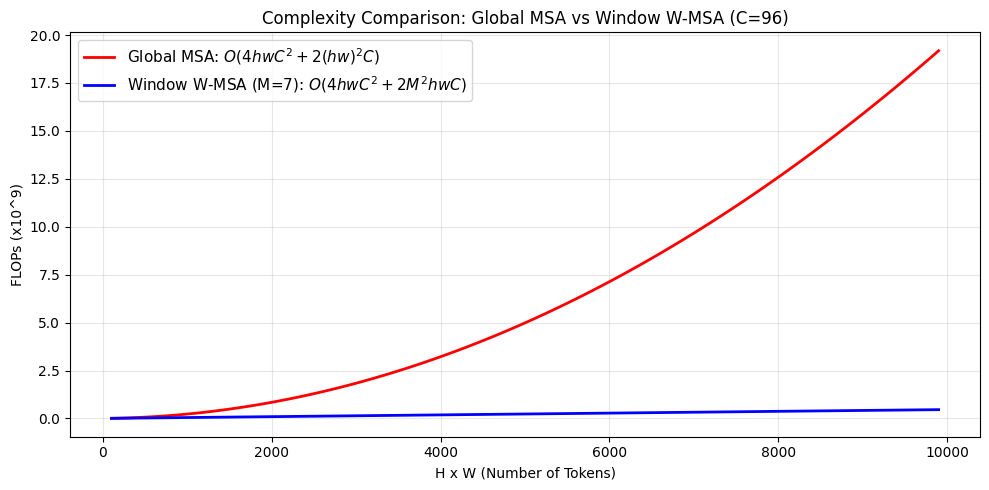

当 H*W = 3136 (56x56) 时:
  全局 MSA: 2.00 GFLOPs
  窗口 W-MSA: 0.15 GFLOPs


In [17]:
# ── 计算复杂度对比 ──
hw_range = np.arange(100, 10000, 100)  # 不同的 H*W
C = 96
M = 7

flops_msa = 4 * hw_range * C**2 + 2 * hw_range**2 * C  # 全局 MSA
flops_wmsa = 4 * hw_range * C**2 + 2 * M**2 * hw_range * C  # 窗口 W-MSA

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hw_range, flops_msa / 1e9, 'r-', linewidth=2, label='Global MSA: $O(4hwC^2 + 2(hw)^2C)$')
ax.plot(hw_range, flops_wmsa / 1e9, 'b-', linewidth=2, label=f'Window W-MSA (M={M}): $O(4hwC^2 + 2M^2hwC)$')
ax.set_xlabel('H x W (Number of Tokens)')
ax.set_ylabel('FLOPs (x10^9)')
ax.set_title('Complexity Comparison: Global MSA vs Window W-MSA (C=96)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(f'当 H*W = 3136 (56x56) 时:')
print(f'  全局 MSA: {(4*3136*96**2 + 2*3136**2*96)/1e9:.2f} GFLOPs')
print(f'  窗口 W-MSA: {(4*3136*96**2 + 2*49*3136*96)/1e9:.2f} GFLOPs')

## 附录 B：面试拓展

### 高频面试题

**Q1: Swin Transformer 解决了 ViT 的哪些问题？**

- **尺度问题**：ViT 使用单一尺度 Patch，无法提取多尺度特征。Swin 通过 Patch Merging 构建金字塔特征图
- **计算复杂度**：ViT 全局自注意力 $O(N^2)$，高分辨率图像计算量爆炸。Swin 用窗口注意力降为 $O(N)$
- **通用性**：ViT 主要用于分类，Swin 可作为通用 backbone 支持检测、分割等密集预测任务

**Q2: W-MSA 的复杂度公式推导？**

全局 MSA 复杂度：$\Omega(\text{MSA}) = 4hwC^2 + 2(hw)^2C$
- $4hwC^2$：QKV 投影 (3次) + 输出投影 (1次)
- $2(hw)^2C$：$QK^T$ 计算 + Attention$\times$V 计算

窗口 W-MSA：将 $hw$ 替换为 $M^2$（每个窗口内），乘以窗口数 $hw/M^2$：
$$\Omega(\text{W-MSA}) = \frac{hw}{M^2} \times [4M^2C^2 + 2(M^2)^2C] = 4hwC^2 + 2M^2hwC$$

当 $M$ 固定时，关于 $hw$ 为**线性**。

**Q3: 循环移位 (Cyclic Shift) + 掩码的具体实现？**

1. `torch.roll(x, shifts=(-M//2, -M//2), dims=(1, 2))` 执行循环移位
2. 移位后同一窗口内可能包含不相邻区域，需要掩码
3. 构造掩码矩阵：同一区域的位置填 0，不同区域填 -100
4. 注意力矩阵 + 掩码后做 softmax，-100 对应位置趋近于 0
5. 计算完成后 `torch.roll` 逆移位恢复原始位置

**Q4: 为什么 Swin Block 总是成对出现（偶数个）？**

- 第 1 个 Block 使用 W-MSA（固定窗口），第 2 个使用 SW-MSA（移动窗口）
- W-MSA 提供窗口内的精细交互，SW-MSA 实现跨窗口信息传递
- 两者交替使用，间接实现了全局建模能力
- 如果只有 W-MSA，窗口之间完全隔离，无法传递信息

**Q5: Patch Merging 与 CNN 中的池化有什么异同？**

| | Patch Merging | 池化 (Pooling) |
|---|---|---|
| 空间缩小 | 2x | 2x |
| 通道变化 | 4C -> 2C（先升后降） | 不变 |
| 参数 | 有（线性层） | 无 |
| 信息保留 | 保留更多（线性组合） | 可能丢失（max/avg） |

**Q6: Swin Transformer 的相对位置偏置 vs ViT 的绝对位置编码？**

- ViT：加在输入 token 上的固定/可学习绝对编码 -> 编码位置信息但不具平移不变性
- Swin：加在注意力矩阵上的相对位置偏置 -> 编码 token 对之间的相对距离 -> 具有更好的位置泛化能力
- 实验表明相对位置偏置效果更好，且更适合变化的输入尺寸

**Q7: Swin Transformer 如何适配检测和分割任务？**

- 通过 Patch Merging 输出多尺度特征图（1/4、1/8、1/16、1/32）
- 这些特征图可直接输入 **FPN**（特征金字塔网络）做目标检测
- 或输入 **U-Net** 解码器做语义分割
- 这是 Swin 相比 ViT 最大的优势之一

**Q8: Swin Transformer V2 做了哪些改进？**

- 将 pre-norm 改为 post-norm，提升训练稳定性
- 用 cosine attention 替代 dot-product attention
- 用 log-spaced continuous position bias 替代参数化的位置偏置表
- 支持更大模型 (3B 参数) 和更高分辨率 (1536x1536)

### 延伸阅读与对比

| 对比维度 | ViT | Swin Transformer | DeiT | CvT |
|---------|-----|------------------|------|-----|
| 核心思想 | 全局注意力 | 移动窗口注意力 | 知识蒸馏 + ViT | 卷积 + Transformer |
| 计算复杂度 | $O(N^2)$ | $O(N)$ | $O(N^2)$ | $O(N)$ |
| 多尺度 | x | o | x | o |
| 位置编码 | 绝对 | 相对偏置 | 绝对 | 卷积隐式编码 |
| ImageNet Top-1 | 86.4% (ViT-L) | 87.3% (Swin-L) | 85.2% (DeiT-B) | 87.7% (CvT-W24) |

### 进阶探索方向

- **Swin V2**：扩展到 3B 参数、1536 分辨率，支持更大规模预训练
- **CSwin Transformer**：交叉形状窗口注意力，进一步改进窗口划分策略
- **Focal Transformer**：焦点注意力，结合局部和全局注意力
- **DAT (Deformable Attention Transformer)**：可变形注意力，自适应调整注意力位置